In [2]:
#Homework 6

In [138]:
# bayesian code
import numpy as np
import matplotlib.pyplot as plt
import math
#import math as factorial

Bayes' theorem
$$
P(H|E) = \frac{P(E|H) \cdot P(H)}{P(E)}
$$

Binomial probability distribution
$$
    P(h|\theta) = 
    \begin{pmatrix}
    n\\
    h
    \end{pmatrix} 
    \theta^h (1 - \theta)^{(n - h)}
$$
Where $h$ is the number of heads, $\theta$ is the probability of getting a head and $n$ is the total number of coin flips.

Beta function
$$
    P(\alpha,\beta,\theta) = \frac{\Gamma (\alpha + \beta)}{\Gamma (\alpha) \Gamma (\beta)} \theta^{(\alpha - 1)} (1-\theta)^{(\beta-1)}
$$
$\Gamma(x)$ is the gamma function

In [154]:
#Bayes' theorem
# P(H|E) = the posterior probability or the probability of H given E
# P(E|H) = the probability of observing E given H
# P(H) = the prior probability (before data is taken) of H being true
# P(E) = the probability only based on the data, which can be thought of as a normalization factor
# Where H is the hypothesis/model and E is the evidence/data. 

def bayesian_inference(prior_fn, likelihood_fn, data, num_points):

    # grid over parameter space
    theta_grid = np.linspace(0, 1, num_points)

    # compute prior P(H) and likelihood P(E|H)
    prior_vals = np.array([prior_fn(theta) for theta in theta_grid])
    likelihood_vals = np.array([likelihood_fn(data, theta) for theta in theta_grid])

    # unnormalized posterior
    posterior_unnormalized = prior_vals * likelihood_vals

    # normalize (numerical integration)
    area = np.trapezoid(posterior_unnormalized, theta_grid)
    posterior = posterior_unnormalized / area

    return theta_grid, posterior

# likelihood P(E|H) -> bionomial probability distribution
def likelihood(data, theta):
    #h, n = data
    n = len(data) # number of flipping
    h = int(sum(data)) # number of head
    #coefficient
    #fact = math.factorial(n) / ( math.factorial(h) * math.factorial(n - h) )
    fact = math.comb(n,h)
    return fact * theta**h * ((1-theta)**(n-h))

# prior P(H) -> beta function 
def beta_func(alpha,beta):
    def prior(theta):
        if theta < 0 or theta > 1:
            return 0.0
        return ( math.gamma(alpha + beta) / ( math.gamma(alpha) * math.gamma(beta) ) ) * \
            theta**(alpha - 1) * ( (1 - theta)**(beta - 1) )
    return prior

#left = factorial(alpha + beta - 1) / ( factorial(alpha - 1) * factorial(beta - 1) )
#right = theta**(alpha - 1) * ( (1 - theta)**(beta - 1) )

# prior P(H) -> beta function 
def beta_like_prior(alpha, beta):
    def prior(theta):
        if theta < 0 or theta > 1:
            return 0.0
        return (theta ** (alpha - 1)) * ((1 - theta) ** (beta - 1))
    return prior

In [ ]:
# using data
# 1 -> head, 0 -> tail
data = np.loadtxt("HW06_data.txt", dtype = 'float', unpack = True, usecols = (0))
sample_sizes = [4, 49, 499] #5, 50, 500 data points
results_2c = []
alpha,beta = 2,2
prior = beta_func(alpha,beta)
num_points = 1000

for n in sample_sizes:
    theta_grid, posterior = bayesian_inference(prior, likelihood, data[:n],num_points)
    results_2c.append((theta_grid, posterior))

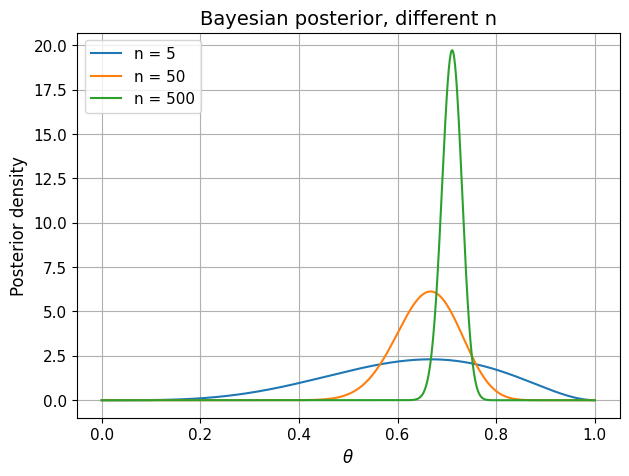

In [263]:
plt.figure(figsize=(7,5))
for n, (theta_grid, posterior) in zip(sample_sizes, results_2c):
    plt.plot(theta_grid, posterior, label=f'n = {n+1}')
plt.xlabel(r"$\theta$",fontsize=12)
plt.ylabel("Posterior density",fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.title(f"Bayesian posterior, different n", fontsize=14)
plt.legend(loc='upper left',fontsize=11)
plt.grid(True)

#print(f'number of flip = {len(data)}, number of head = {int(sum(data))}' )

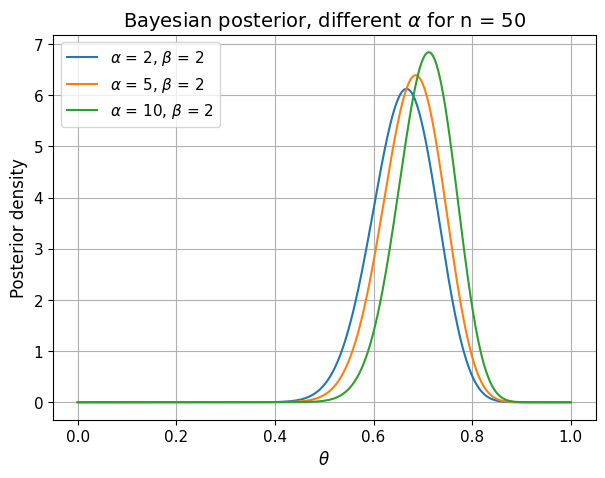

In [271]:
alphas = [2, 5, 10]
beta = 2
n_second = 49
results_2d = []

for alpha in alphas:
    prior = beta_func(alpha, beta)
    theta_grid, posterior = bayesian_inference(prior,likelihood,data[:n_second],num_points)
    results_2d.append((alpha, theta_grid, posterior))

plt.figure(figsize=(7,5))
for alpha, theta_grid, posterior in results_2d:
    plt.plot(theta_grid, posterior, label=fr'$\alpha$ = {alpha}, $\beta$ = {beta}')

plt.xlabel(r"$\theta$",fontsize=12)
plt.ylabel("Posterior density",fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.title(fr"Bayesian posterior, different $\alpha$ for n = {n_second+1}", fontsize=14)
plt.legend(loc='upper left',fontsize=11)
plt.grid(True)

In [181]:
# Problem 3, estimating the value of pi
import random

# Number of random points
n_values = [10, 100, 1000, 10000]

# Generate points
def circle(n):
    inside_x = []
    inside_y = []
    outside_x = []
    outside_y = []
    data_pi = []
    inside_count = 0
    outside_count = 0
    for _ in range(n):
        x = random.random()
        y = random.random()
        
        if x**2 + y**2 <= 1:
            inside_x.append(x)
            inside_y.append(y)
            data_pi.append(1)
            inside_count += 1
        else:
            outside_x.append(x)
            outside_y.append(y)
            data_pi.append(0)
            outside_count += 1
    return data_pi, inside_count

#data_pi, inside_count = circle(n_pi)
#print(f"Total points: {n_pi}, inside : {inside_count}")

In [304]:
# implementing Bayesian code for this problem

errors = []
pi_calc = []

print("   n  | Inside | P(inside) | pi | err_rel")
for n in n_values:
    data_pi, inside_count = circle(n)

    # Posterior mean
    alpha,beta = 2,2 #assuming equal weight
    theta_est = (alpha + inside_count) / (alpha + beta + n)
    pi_est = 4 * theta_est
    pi_calc.append(pi_est)

    # Relative error
    err_rel = abs(np.pi - pi_est) / np.pi
    errors.append(err_rel)

    #print(f"\nn = {n}")
    #print(f"Inside count: {inside_count}")
    #print(f"Estimated P(inside): {theta_est:.5f}")
    #print(f"Estimated pi: {pi_est:.5f}")
    #print(f"Relative error: {err_rel*100:.3f}%")

    print(f"{n:5} | {inside_count:5} | {theta_est:.5f} | {pi_est:.5f} | {err_rel*100:.3f}%")

   n  | Inside | P(inside) | pi | err_rel
   10 |     7 | 0.64286 | 2.57143 | 18.149%
  100 |    78 | 0.76923 | 3.07692 | 2.058%
 1000 |   791 | 0.78984 | 3.15936 | 0.566%
10000 |  7827 | 0.78259 | 3.13035 | 0.358%


In [223]:
pi_calc

[2.857142857142857, 3.1538461538461537, 3.247011952191235, 3.1555377848860457]

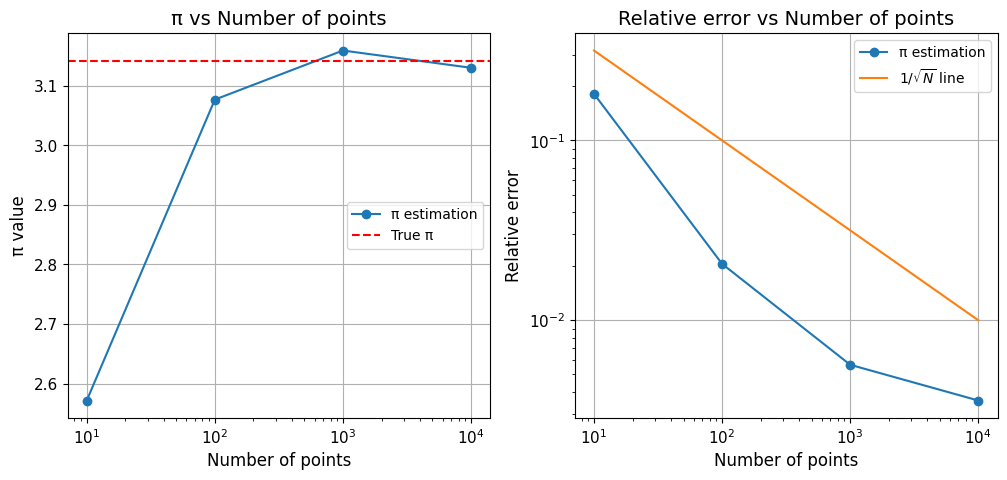

In [305]:
# Plot
relation = 1 / np.sqrt(n_values)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(n_values, pi_calc, marker='o', label = "π estimation")
plt.axhline(np.pi, color='red', linestyle='--', label='True π')
plt.xscale('log')
plt.xlabel("Number of points", fontsize=12)
plt.ylabel("π value", fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.title("π vs Number of points", fontsize=14)
plt.grid(True)
plt.legend(loc='center right')

plt.subplot(1,2,2)
plt.plot(n_values, errors, marker='o', label = "π estimation")
plt.plot(n_values, relation, label = r"$1/\sqrt{N}$ line")
plt.xscale('log')
plt.yscale('log')  # better visualization
plt.xlabel("Number of points", fontsize=12)
plt.ylabel("Relative error", fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.title("Relative error vs Number of points", fontsize=14)
plt.grid(True)
plt.legend(loc='upper right')

In [348]:
n_3d = 100
data_pi, inside_count = circle(n_3d)

alpha_values = [2, 5, 10, 20, 40] 
beta = 2  
pi_calc_3d = []
error_3d = []
print(inside_count)
print("alpha | theta_est | pi_est | err_rel")

for alpha in alpha_values:
    theta_est = (alpha + inside_count) / (alpha + beta + n)
    pi_est = 4 * theta_est
    pi_calc_3d.append(pi_est)
    err_rel = abs(np.pi - pi_est) / np.pi
    error_3d.append(err_rel)

    print(f"{alpha:5} | {theta_est:.5f} | {pi_est:.5f} | {err_rel*100:.3f}%")

74
alpha | theta_est | pi_est | err_rel
    2 | 0.73077 | 2.92308 | 6.956%
    5 | 0.73832 | 2.95327 | 5.994%
   10 | 0.75000 | 3.00000 | 4.507%
   20 | 0.77049 | 3.08197 | 1.898%
   40 | 0.80282 | 3.21127 | 2.218%


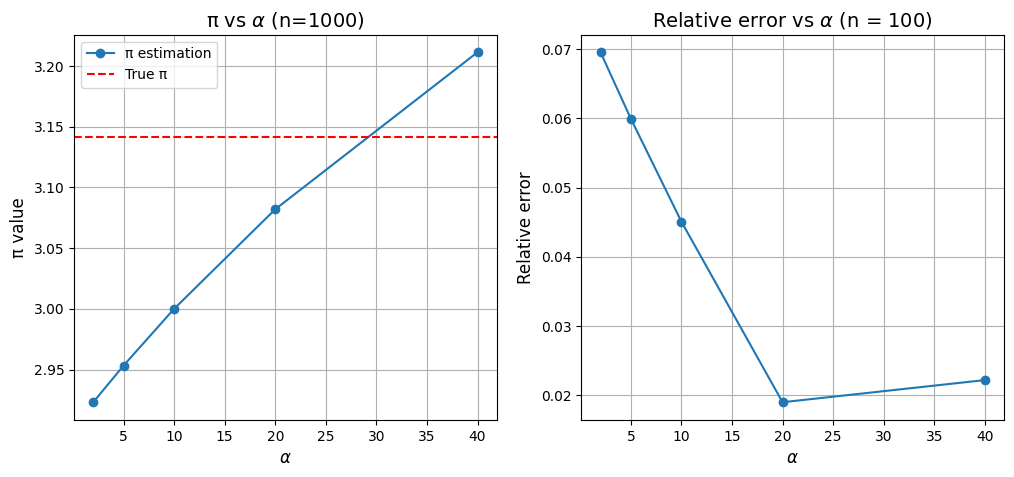

In [349]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(alpha_values, pi_calc_3d, marker='o', label="π estimation")
plt.axhline(np.pi, color='red', linestyle='--', label='True π')
#plt.xscale('log')
plt.xlabel(r"$\alpha$", fontsize=12)
plt.ylabel("π value", fontsize=12)
plt.title(r"π vs $\alpha$ (n=1000)", fontsize=14)
plt.grid(True)
plt.legend(loc='best')


plt.subplot(1,2,2)
plt.plot(alpha_values, error_3d, marker='o', label="Relative error")
#plt.xscale('log')
#plt.yscale('log')
plt.xlabel(r"$\alpha$", fontsize=12)
plt.ylabel("Relative error", fontsize=12)
plt.title(fr"Relative error vs $\alpha$ (n = {n_3d})", fontsize=14)
plt.grid(True)
#plt.legend(loc='best')

#plt.tight_layout()
#plt.show()

(0.0, 1.0)

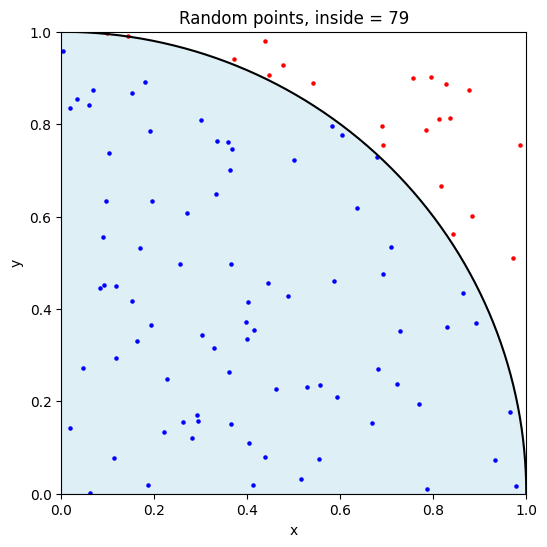

In [107]:
# Create a quarter circle region
theta = np.linspace(0, np.pi/2, 200)
x_circle = np.cos(theta)
y_circle = np.sin(theta)

plt.figure(figsize=(6,6))
# Plot shaded region
plt.fill_between(x_circle, y_circle, 0, color='lightblue', alpha=0.4, label='Quarter Circle')

# Plot points
plt.scatter(inside_x, inside_y, s=5, color='blue', label='Inside')
plt.scatter(outside_x, outside_y, s=5, color='red', label='Outside')

# Draw circle boundary
plt.plot(x_circle, y_circle, color='black')

# Formatting
plt.title(f"Random points, inside = {inside_count}")
plt.xlabel("x")
plt.ylabel("y")
#plt.legend(loc='upper right', fontsize=8)
#plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(0, 1)
plt.ylim(0, 1)

Estimated P(inside): 0.7500000000000002
Estimated pi: 3.000000000000001
